In [4]:
import os, sys, json, pickle, itertools, numpy as np, pandas as pd, scipy.sparse as sp
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_auc_score
import networkx as nx



import sys
sys.path.append('..')


In [5]:
data_path = "data"

In [6]:
import anndata

adata = anndata.read_h5ad("/home/jcr222/workspace/STAGED/data/axalotl_b/axolotl_ran.h5ad")
adata

/home/jcr222/workspace/STAGED/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 11716 × 16556
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'dpi', 'Annotation_grouped', 'dpt_pseudotime', 'time_bin'
    uns: 'diffmap_evals', 'iroot', 'neighbors'
    obsm: 'Geneformer_feats', 'LR_feats', 'Spatial_PCA_feats', 'X_diffmap', 'X_gaga_2stage_gene', 'X_gaga_2stage_spatial', 'X_geneformer', 'X_pca', 'X_pca_harmony', 'X_phate_gene', 'X_phate_spatial', 'X_spatial', 'X_spatial_feats', 'X_spatial_feats_pca', 'celltype_nbrhood', 'spatial'
    varm: 'pcs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [7]:
spatial_traj = np.load("/nfs/roberts/project/pi_sk2433/bp542/MIOFlow_lite/notebooks/strajs.npy",allow_pickle=True)
gene_traj = np.load('/nfs/roberts/project/pi_sk2433/bp542/MIOFlow_lite/notebooks/gtrajs.npy',allow_pickle=True)

In [8]:
data = {}

In [9]:
data['gene_expression'] = gene_traj

In [10]:
data['gene_expression'].shape

(500, 100, 16556)

In [11]:
import scanpy as sc

# Compute highly variable genes
sc.pp.highly_variable_genes(
    adata,
    flavor='seurat',      # or 'cell_ranger' / 'seurat_v3'
    n_top_genes=100,     # adjust as needed
    subset=False,         # set True if you want to keep only HVGs
    inplace=True
)

# Optional: view results
adata.var[['highly_variable', 'means', 'dispersions']].head()

,highly_variable,means,dispersions
new_name,,,
LOC101953204[nr]|ZNF850[hs] | AMEX60DD000003,False,0.059720,0.580781
LOC115462503[nr]|ZNF268[hs] | AMEX60DD000004,False,0.022951,0.800644
AMEX60DD000005,False,0.022617,0.611370
AMEX60DD000008,False,0.004514,0.581143
AMEX60DD000011,False,0.006466,1.460861


In [12]:
import numpy as np
import torch

# 1. Highly variable genes
hvg_mask = adata.var['highly_variable'].values
hvg_genes = adata.var_names[hvg_mask]
n_hvg = len(hvg_genes)

# 2. Fully connected GRN (no self-loops)
full_grn = np.ones((n_hvg, n_hvg), dtype=np.float32)
np.fill_diagonal(full_grn, 0.0)
full_grn_tensor = torch.tensor(full_grn, dtype=torch.float32)

# 3. Store genes
data['genes'] = hvg_genes

# 4. Cell type assignments (from AnnData)
cell_types = adata.obs['Annotation'].values

unique_cell_types = sorted(set(cell_types))
label_to_int = {label: idx for idx, label in enumerate(unique_cell_types)}

assignments = [label_to_int[label] for label in cell_types]
data['cell_type_assignments'] = torch.tensor(assignments, dtype=torch.long)

# 5. Prior GRNs (one per cell type)
cell_specific_prior_grns = [full_grn_tensor.clone() for _ in unique_cell_types]
data['prior_grns'] = cell_specific_prior_grns

# 6. Subset gene expression to HVGs
data['gene_expression'] = data['gene_expression'][:, :, hvg_mask]

# 7. Update dimensions
data['n_genes'] = n_hvg
data['n_cells'] = data['gene_expression'].shape[1]
data['n_time_points'] = data['gene_expression'].shape[0]

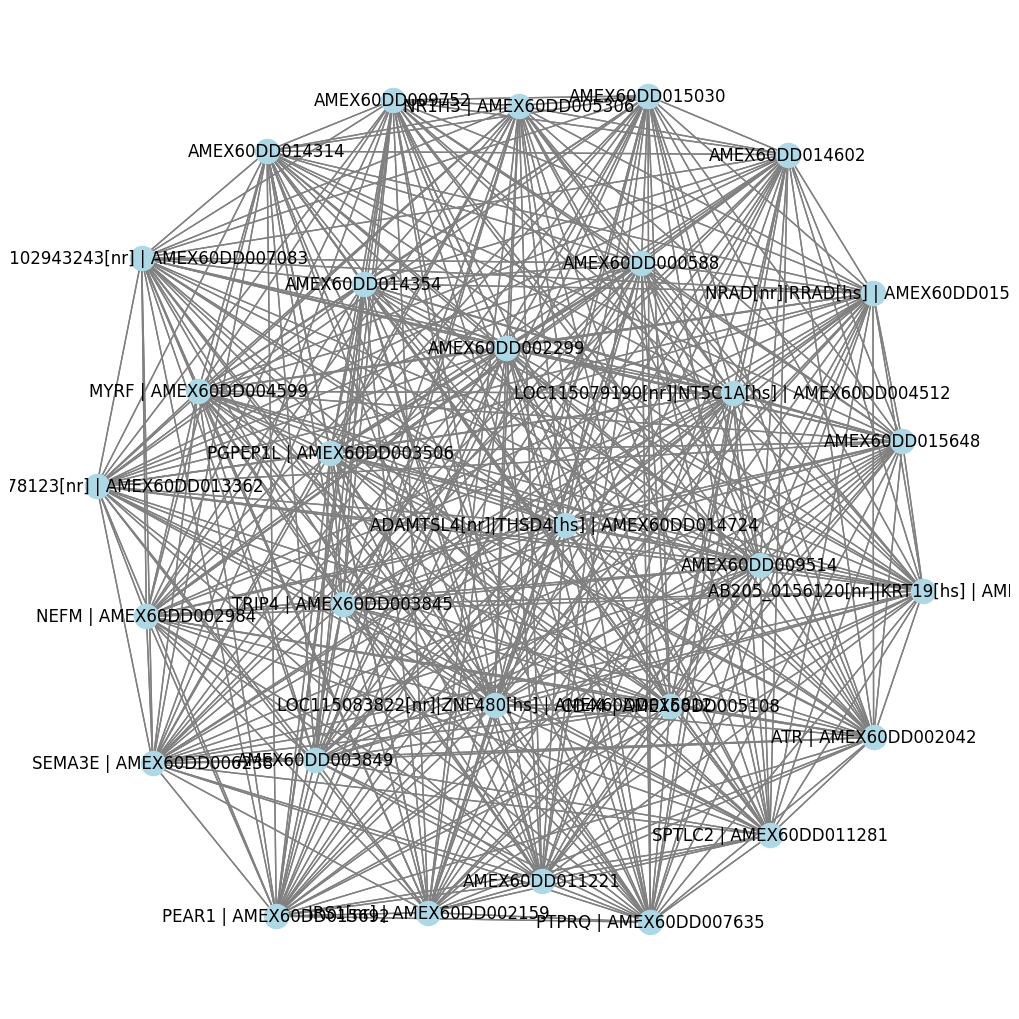

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

top_genes = list(data['genes'])     # <-- fix
top_data = full_grn                # or your GRN matrix

# (strongly recommended) limit size
max_genes = 30
indices = np.arange(min(len(top_genes), max_genes))

sub_data = top_data[np.ix_(indices, indices)]
sub_genes = [top_genes[i] for i in indices]

G = nx.DiGraph()

# Add nodes
for i, label in enumerate(sub_genes):
    G.add_node(i, label=label)

# Add edges (fully connected → skip diagonal)
for i in range(sub_data.shape[0]):
    for j in range(sub_data.shape[1]):
        if i != j and sub_data[i, j] > 0:
            G.add_edge(i, j)

labels = nx.get_node_attributes(G, 'label')

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    labels=labels,
    node_size=300,
    node_color='lightblue',
    edge_color='gray',
    arrows=False
)

plt.show()

In [14]:
LR_pairs = pd.read_csv("/nfs/roberts/project/pi_sk2433/bp542/Axolotl_Spatial/ARTISTA_LR_pairs.csv")
lr_pairs = list(LR_pairs['Ligand'])  + list(LR_pairs['Receptor'])

In [15]:
# 8. L-R pairs from the ARTISTA CSV; R-G pairs are each receptor paired to itself
import pandas as pd
lr_df = pd.read_csv("/nfs/roberts/project/pi_sk2433/bp542/Axolotl_Spatial/ARTISTA_LR_pairs.csv")
ligand_receptor_pairs = list(zip(lr_df['Ligand'], lr_df['Receptor']))
receptor_gene_pairs   = [(r, r) for r in sorted(set(lr_df['Receptor']))]

valid_genes = set(data['genes'])
print(f"Valid genes in axolotl data: {len(valid_genes)} HVGs")
print(f"Loaded {len(ligand_receptor_pairs)} L-R pairs from ARTISTA CSV")

filtered_lr_pairs = []
dropped_lr = 0
for ligand, receptor in ligand_receptor_pairs:
    if ligand in valid_genes and receptor in valid_genes:
        filtered_lr_pairs.append((ligand, receptor))
    else:
        dropped_lr += 1
data['ligand_receptor_pairs'] = filtered_lr_pairs

filtered_rg_pairs = []
dropped_rg = 0
for receptor, gene in receptor_gene_pairs:
    if receptor in valid_genes and gene in valid_genes:
        filtered_rg_pairs.append((receptor, gene))
    else:
        dropped_rg += 1
data['receptor_gene_pairs'] = filtered_rg_pairs

print(f"L-R pairs after HVG filter: {len(filtered_lr_pairs)} kept, {dropped_lr} dropped")
print(f"R-G pairs after HVG filter: {len(filtered_rg_pairs)} kept, {dropped_rg} dropped")

Valid genes in axolotl data: 100 HVGs
Loaded 640 L-R pairs from ARTISTA CSV
L-R pairs after HVG filter: 0 kept, 640 dropped
R-G pairs after HVG filter: 2 kept, 227 dropped


In [16]:
# notebooks/precompute_axolotl.py  (or a .ipynb cell)
import os, pickle
import numpy as np
import pandas as pd
import anndata
import scanpy as sc

OUT_DIR = "data/axalotl"
os.makedirs(OUT_DIR, exist_ok=True)

# 1. Load raw inputs
adata = anndata.read_h5ad("/home/jcr222/workspace/STAGED/data/axalotl_b/axolotl_ran.h5ad")
spatial_traj = np.load("/nfs/roberts/project/pi_sk2433/bp542/MIOFlow_lite/notebooks/strajs.npy", allow_pickle=True)
gene_traj    = np.load("/nfs/roberts/project/pi_sk2433/bp542/MIOFlow_lite/notebooks/gtrajs.npy", allow_pickle=True)
lr_df        = pd.read_csv("/nfs/roberts/project/pi_sk2433/bp542/Axolotl_Spatial/ARTISTA_LR_pairs.csv")

# 2. HVGs
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=100, subset=False, inplace=True)
hvg_mask  = adata.var['highly_variable'].values
hvg_genes = adata.var_names[hvg_mask].tolist()

# 3. Subset gene expression to HVGs
gene_expr_hvg = gene_traj[:, :, hvg_mask]   # (T, N, n_hvg)

# 4. Cell-type assignments as int labels (+ keep the mapping for sanity)
cell_types        = adata.obs['Annotation'].values
unique_cell_types = sorted(set(cell_types))
label_to_int      = {label: idx for idx, label in enumerate(unique_cell_types)}
assignments       = np.array([label_to_int[c] for c in cell_types], dtype=np.int64)


# 5. Prior GRNs: fully connected DiGraphs, keyed by integer cell-type id
#    (matches cell_type_assignments, which uses label_to_int values)
prior_grns = {}
for cell_type, idx in label_to_int.items():
    print(idx)
    G = nx.DiGraph()
    G.add_nodes_from(hvg_genes)
    G.add_edges_from(
        (src, dst) for src in hvg_genes for dst in hvg_genes if src != dst
    )
    prior_grns[idx] = G

# 6. L-R / R-G pairs, filtered to HVGs
valid = set(hvg_genes)
ligand_receptor_pairs = [(l, r) for l, r in zip(lr_df['Ligand'], lr_df['Receptor'])
                         if l in valid and r in valid]
receptor_gene_pairs   = [(r, r) for r in sorted({r for _, r in ligand_receptor_pairs})]

print(f"HVGs: {n_hvg}")
print(f"L-R pairs kept: {len(ligand_receptor_pairs)} / {len(lr_df)}")
print(f"R-G pairs kept: {len(receptor_gene_pairs)}")
print(f"Cell types: {len(unique_cell_types)}  → {label_to_int}")

# 7. Bundle and save as a single pickle
bundle = {
    'gene_expression':       gene_expr_hvg,         # numpy
    'cell_positions':        spatial_traj,          # numpy
    'genes':                 hvg_genes,             # list[str]
    'cell_type_assignments': assignments,           # numpy
    'prior_grns':            prior_grns,            # list[numpy]
    'ligand_receptor_pairs': ligand_receptor_pairs, # list[tuple]
    'receptor_gene_pairs':   receptor_gene_pairs,   # list[tuple]
    'label_to_int':          label_to_int,          # bonus, for debugging
}
with open(os.path.join(OUT_DIR, "axalotl_processed.pkl"), "wb") as f:
    pickle.dump(bundle, f)
print(f"Saved → {os.path.join(OUT_DIR, 'axalotl_processed.pkl')}")

/home/jcr222/workspace/STAGED/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


0
1
2
3
4
5
6
HVGs: 100
L-R pairs kept: 0 / 640
R-G pairs kept: 0
Cell types: 7  → {'IMN': 0, 'nptxEX': 1, 'rIPC1': 2, 'rIPC2': 3, 'rIPC3': 4, 'rIPC4': 5, 'reaEGC': 6}
Saved → data/axalotl/axalotl_processed.pkl


In [22]:
import pickle
with open("/home/jcr222/workspace/STAGED/data/axalotl/axalotl_processed.pkl", "rb") as f:
    bundle = pickle.load(f)
print(type(bundle['prior_grns']))
print(list(bundle['prior_grns'].keys())[:5])
print([type(k) for k in list(bundle['prior_grns'].keys())[:5]])

<class 'dict'>
[0, 1, 2, 3, 4]
[<class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>]
